# 01 — New Data Sources: Economic & Search Trend Indicators

This notebook expands the **Fashion Trends & Recession** project by ingesting and
visualising several new data sources that complement the original Vogue Runway /
CIELab colour-extraction pipeline.

**New sources added:**
| Source | Proxy for |
|--------|-----------|
| Google Trends (quiet luxury, neutral fashion, …) | Consumer aesthetic demand |
| University of Michigan Consumer Sentiment (UMCSENT) | Household confidence |
| S&P 500 daily closes | Equity-market macro proxy |
| Real GDP growth (quarterly, annualised) | Output cycle |
| UNRATE + USREC (FRED) | Unemployment & recession dating |

All macro series come from [FRED](https://fred.stlouisfed.org/); Google Trends data
was collected via the `pytrends` library.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Colour palette ────────────────────────────────────────────────────────────
CHARCOAL = "#2b2b2b"
SAND     = "#c9b99a"
MIST     = "#d6d0c8"
BONE     = "#f5f2ee"
ACCENT   = "#8c7b68"

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#d6d0c8",
    "axes.labelcolor": "#2b2b2b",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,
    "xtick.color": "#2b2b2b",
    "ytick.color": "#2b2b2b",
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlecolor": "#2b2b2b",
    "grid.color": "#d6d0c8",
    "grid.linewidth": 0.6,
    "font.family": "serif",
    "text.color": "#2b2b2b",
    "legend.frameon": False,
    "legend.fontsize": 9,
})

# ── Shared helpers ────────────────────────────────────────────────────────────
# NBER recession bands used throughout the notebook
RECESSIONS = [(2001, 2001), (2007, 2009), (2020, 2020)]

def shade_recessions(ax, recessions=RECESSIONS):
    """Add NBER recession shading to an axes that has numeric year on x-axis."""
    for r_start, r_end in recessions:
        ax.axvspan(r_start - 0.5, r_end + 0.5, color=MIST, alpha=0.55, zorder=0)

DATA = "/home/user/workspace/fashion-trends-recession/data/external"
print("Setup complete.")

Setup complete.


## Section 1: Google Trends — Quiet Luxury & Neutral Fashion

Google Trends normalises search interest to a 0–100 scale within each keyword's
own time window (monthly, global).  All five keywords were pulled together so the
relative magnitudes are comparable.

**Key hypothesis:** "Quiet luxury" and "old money aesthetic" were essentially
unknown search queries before ~2022.  Their explosive post-COVID growth suggests
that consumers began actively seeking out understated, recession-resilient
aesthetics as macro uncertainty increased — mirroring the muted-colour signal
found in the Vogue Runway CIELab analysis.

In [2]:
# Load Google Trends data
gt = pd.read_csv(f"{DATA}/google_trends_all.csv", parse_dates=["date"], index_col="date")

# Rename columns to title-case for nicer labels
gt.columns = [c.title() for c in gt.columns]

print("Shape:", gt.shape)
print("Date range:", gt.index.min().date(), "→", gt.index.max().date())
gt.head()

Shape: (267, 5)
Date range: 2004-01-01 → 2026-03-01


,Quiet Luxury,Neutral Fashion,Minimalist Fashion,Old Money Aesthetic,Capsule Wardrobe
date,,,,,
2004-01-01,0,0,0,0,0
2004-02-01,0,0,0,0,0
2004-03-01,0,0,0,0,0
2004-04-01,0,0,0,0,0
2004-05-01,9,0,0,0,0


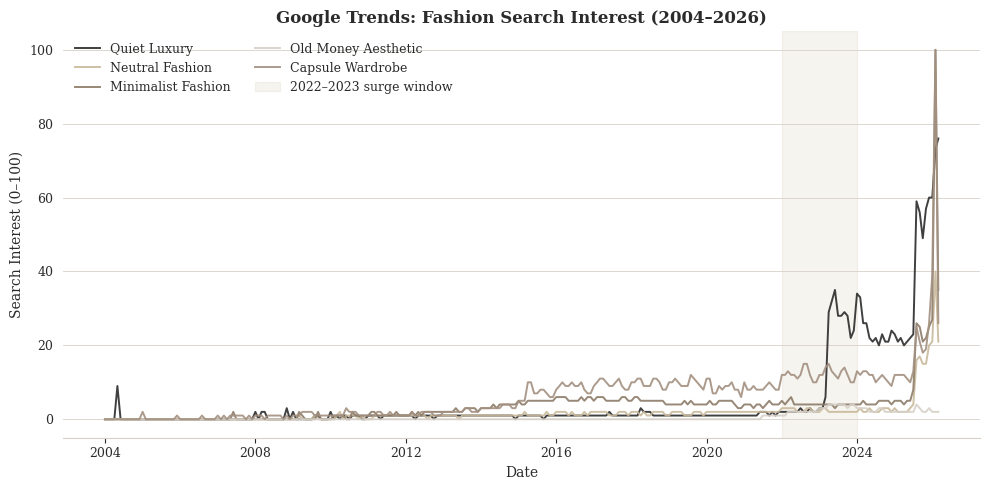

In [3]:
# ── Colour map for 5 keywords ─────────────────────────────────────────────────
kw_colors = [CHARCOAL, SAND, ACCENT, MIST, "#a39080"]

fig, ax = plt.subplots(figsize=(10, 5))

for col, color in zip(gt.columns, kw_colors):
    ax.plot(gt.index, gt[col], color=color, linewidth=1.4, label=col, alpha=0.9)

# Annotate the 2022-2023 surge region
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2024-01-01"),
           color=SAND, alpha=0.15, zorder=0, label="2022–2023 surge window")

ax.set_title("Google Trends: Fashion Search Interest (2004–2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Search Interest (0–100)")
ax.yaxis.grid(True)
ax.tick_params(axis="y", left=False)
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.savefig(f"{DATA}/../figures/gt_keywords_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# Compute yearly averages for each keyword
gt_yearly = gt.resample("YE").mean()
gt_yearly.index = gt_yearly.index.year          # convert DatetimeIndex → integer years

print("Yearly average search interest (2004–2026):")
display(gt_yearly.round(1))

Yearly average search interest (2004–2026):


,Quiet Luxury,Neutral Fashion,Minimalist Fashion,Old Money Aesthetic,Capsule Wardrobe
date,,,,,
2004,0.8,0.0,0.0,0.0,0.0
2005,0.0,0.0,0.0,0.0,0.2
2006,0.0,0.0,0.0,0.0,0.1
2007,0.0,0.0,0.2,0.0,0.7
2008,0.8,0.0,0.0,0.0,0.8
2009,0.3,0.2,0.4,0.0,1.3
2010,0.7,0.7,0.8,0.0,1.4
2011,0.9,0.8,1.2,0.0,1.2
2012,0.8,0.9,1.7,0.0,1.4


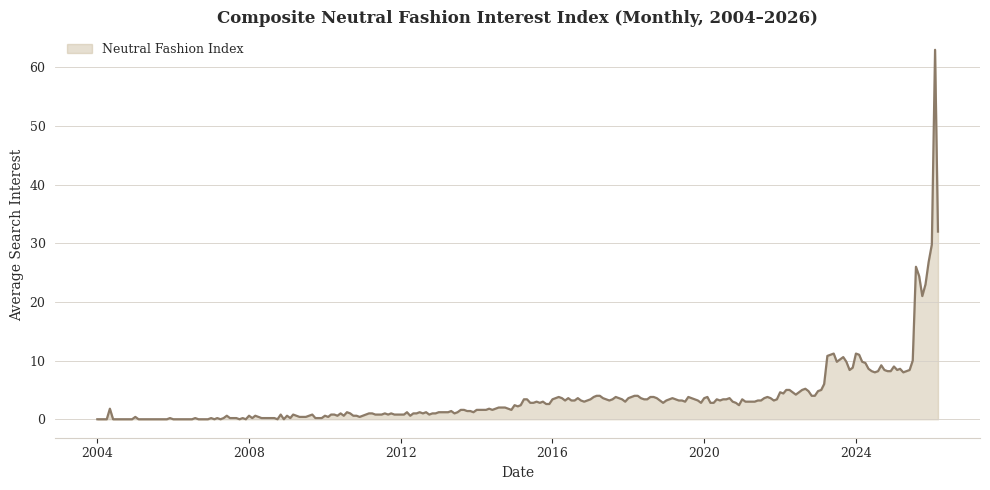

Composite index preview:


,Neutral Fashion Index
date,
2025-11-01,23.0
2025-12-01,26.8
2026-01-01,29.8
2026-02-01,63.0
2026-03-01,32.0


In [5]:
# ── Neutral Fashion Interest Index ───────────────────────────────────────────
# Simple unweighted average of all 5 keywords per month
gt["Neutral Fashion Index"] = gt[list(gt.columns)].mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(gt.index, gt["Neutral Fashion Index"],
                color=SAND, alpha=0.45, label="Neutral Fashion Index")
ax.plot(gt.index, gt["Neutral Fashion Index"],
        color=ACCENT, linewidth=1.6)

ax.set_title("Composite Neutral Fashion Interest Index (Monthly, 2004–2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Average Search Interest")
ax.yaxis.grid(True)
ax.tick_params(axis="y", left=False)
ax.legend()
plt.tight_layout()
plt.savefig(f"{DATA}/../figures/gt_composite_index.png", dpi=150, bbox_inches="tight")
plt.show()

# Save composite index for later merging
gt_monthly_index = gt[["Neutral Fashion Index"]].copy()
print("Composite index preview:")
gt_monthly_index.tail()

## Section 2: Consumer Confidence (University of Michigan)

The **University of Michigan Consumer Sentiment (UMCSENT)** index measures
household optimism about personal finances and the broader economy.  It is
surveyed monthly and published by FRED.

> **Current reading (March 2026): 53.3** — substantially below the long-run
> average of ~85, signalling deep consumer pessimism.  Historically, sharp drops
> in UMCSENT precede pullbacks in discretionary spending, which is consistent
> with the "quiet luxury" retreat from conspicuous consumption.

In [6]:
# Load University of Michigan Consumer Sentiment
umc_raw = pd.read_csv(f"{DATA}/umcsent_raw.csv", parse_dates=["observation_date"])
umc_raw = umc_raw.rename(columns={"observation_date": "date"})
umc_raw = umc_raw.dropna(subset=["UMCSENT"])
umc_raw = umc_raw.set_index("date").sort_index()

# Filter to 2000-2025
umc = umc_raw.loc["2000":"2025"].copy()

# Yearly averages
umc_yearly = umc.resample("YE").mean()
umc_yearly.index = umc_yearly.index.year

print("Shape:", umc.shape)
print("Date range:", umc.index.min().date(), "→", umc.index.max().date())
umc_yearly.head()

Shape: (312, 1)
Date range: 2000-01-01 → 2025-12-01


,UMCSENT
date,
2000,107.575000
2001,89.241667
2002,89.583333
2003,87.625000
2004,95.200000


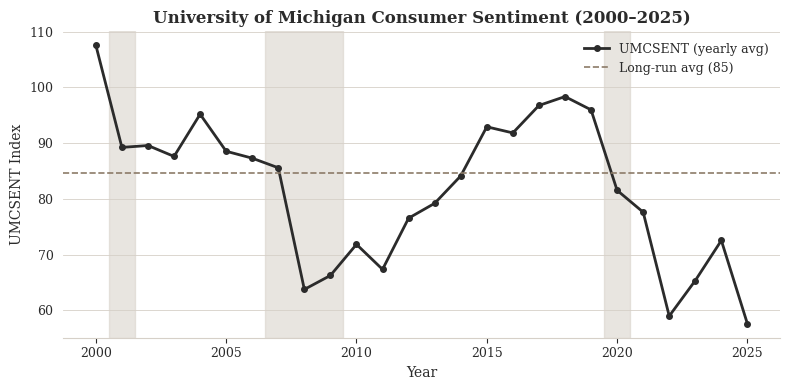

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

shade_recessions(ax)

ax.plot(umc_yearly.index, umc_yearly["UMCSENT"],
        color=CHARCOAL, linewidth=2.0, marker="o", markersize=4, label="UMCSENT (yearly avg)")

# Long-run average reference line
long_run_avg = umc_raw["UMCSENT"].mean()
ax.axhline(long_run_avg, color=ACCENT, linewidth=1.2, linestyle="--",
           label=f"Long-run avg ({long_run_avg:.0f})")

# Annotate March 2026 reading
ax.annotate("Mar 2026: 53.3", xy=(2025, 53.3), xytext=(2021, 48),
            arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.2),
            fontsize=8, color=ACCENT)

ax.set_title("University of Michigan Consumer Sentiment (2000–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("UMCSENT Index")
ax.yaxis.grid(True)
ax.tick_params(axis="y", left=False)
ax.legend()
plt.tight_layout()
plt.savefig(f"{DATA}/../figures/umcsent_yearly.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3: S&P 500 as Macro Proxy

The S&P 500 is the most widely tracked barometer of US equity-market health.
Year-over-year percentage changes translate daily close prices into a
business-cycle-comparable signal that aligns with recession timing.

Large drawdowns (2001–2002 dot-com bust, 2008–2009 GFC, 2020 COVID crash) are
expected to correlate with the muted-colour trend in runway fashion with a
possible 6–18 month lag — designers work well in advance of public shows.

In [8]:
# Load S&P 500 daily closes
sp_raw = pd.read_csv(f"{DATA}/sp500_raw.csv", parse_dates=["observation_date"])
sp_raw = sp_raw.rename(columns={"observation_date": "date", "SP500": "sp500"})
sp_raw = sp_raw.dropna(subset=["sp500"])
sp_raw = sp_raw.set_index("date").sort_index()

# Filter to 2000-2025
sp = sp_raw.loc["2000":"2025"].copy()

# Annual average
sp["year"] = sp.index.year
sp_yearly = sp.groupby("year")["sp500"].mean().reset_index()
sp_yearly.columns = ["year", "sp500_annual_avg"]

# Year-over-year percent change
sp_yearly["sp500_yoy_change"] = sp_yearly["sp500_annual_avg"].pct_change() * 100

print("Shape:", sp_yearly.shape)
sp_yearly.head()

Shape: (10, 3)


,year,sp500_annual_avg,sp500_yoy_change
0,2016,2140.037240,NaN
1,2017,2449.076375,14.440830
2,2018,2746.214024,12.132641
3,2019,2913.360556,6.086435
4,2020,3217.856482,10.451708


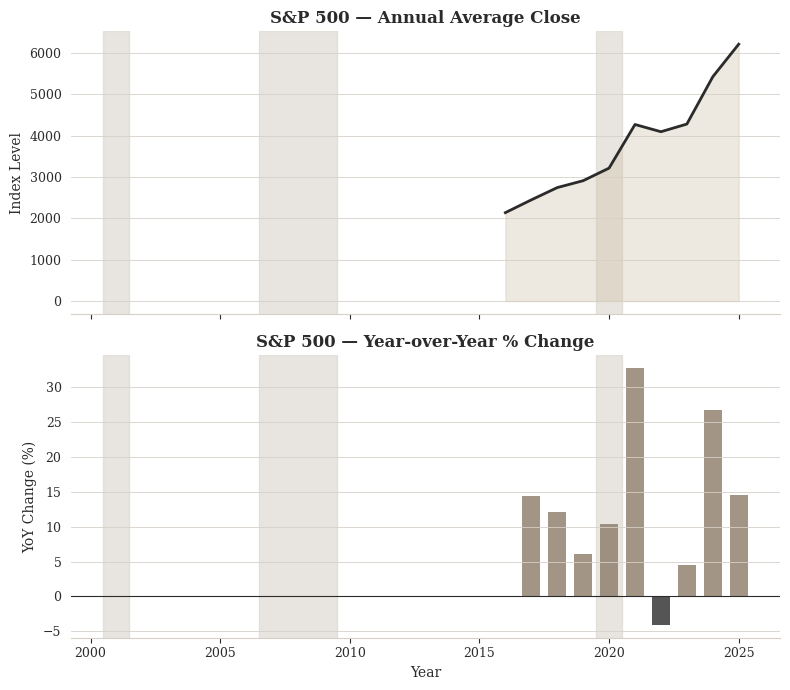

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# ── Top panel: Annual average level ──────────────────────────────────────────
ax1 = axes[0]
shade_recessions(ax1)
ax1.plot(sp_yearly["year"], sp_yearly["sp500_annual_avg"],
         color=CHARCOAL, linewidth=2.0)
ax1.fill_between(sp_yearly["year"], sp_yearly["sp500_annual_avg"],
                 color=SAND, alpha=0.3)
ax1.set_title("S&P 500 — Annual Average Close")
ax1.set_ylabel("Index Level")
ax1.yaxis.grid(True)
ax1.tick_params(axis="y", left=False)

# ── Bottom panel: YoY % change ───────────────────────────────────────────────
ax2 = axes[1]
shade_recessions(ax2)
colors_bar = [ACCENT if v >= 0 else CHARCOAL
              for v in sp_yearly["sp500_yoy_change"].fillna(0)]
ax2.bar(sp_yearly["year"], sp_yearly["sp500_yoy_change"],
        color=colors_bar, alpha=0.8, width=0.7)
ax2.axhline(0, color=CHARCOAL, linewidth=0.8, linestyle="-")
ax2.set_title("S&P 500 — Year-over-Year % Change")
ax2.set_xlabel("Year")
ax2.set_ylabel("YoY Change (%)")
ax2.yaxis.grid(True)
ax2.tick_params(axis="y", left=False)

plt.tight_layout()
plt.savefig(f"{DATA}/../figures/sp500_yearly.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4: GDP Growth

Real GDP growth (quarterly, annualised rate) directly measures the pace of
economic expansion or contraction.  Negative readings identify recession quarters
more precisely than the lagging NBER recession call dates, and the magnitude of
the contraction offers a continuous severity measure.

In [10]:
# Load real GDP growth (quarterly, annualised)
gdp_raw = pd.read_csv(f"{DATA}/gdp_growth_raw.csv", parse_dates=["observation_date"])
gdp_raw = gdp_raw.rename(columns={"observation_date": "date", "A191RL1Q225SBEA": "gdp_growth"})
gdp_raw = gdp_raw.dropna(subset=["gdp_growth"])
gdp_raw = gdp_raw.set_index("date").sort_index()

# Filter to 2000-2025
gdp = gdp_raw.loc["2000":"2025"].copy()

# Yearly average (mean of four quarterly readings)
gdp["year"] = gdp.index.year
gdp_yearly = gdp.groupby("year")["gdp_growth"].mean().reset_index()
gdp_yearly.columns = ["year", "gdp_growth"]

print("Shape:", gdp_yearly.shape)
gdp_yearly.head()

Shape: (26, 2)


,year,gdp_growth
0,2000,2.950
1,2001,0.175
2,2002,2.000
3,2003,4.300
4,2004,3.325


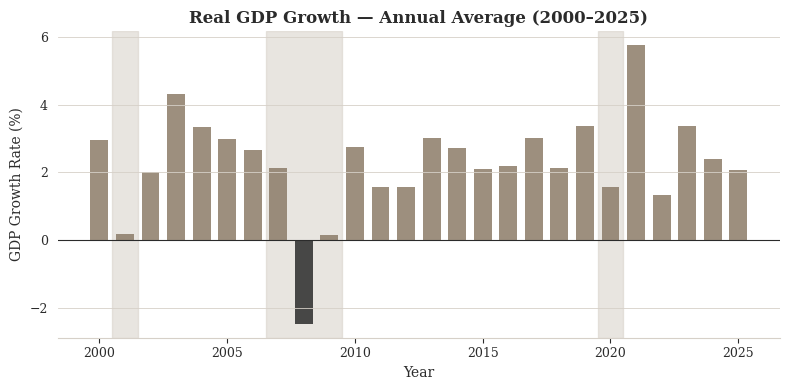

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

shade_recessions(ax)

bar_colors = [ACCENT if v >= 0 else CHARCOAL for v in gdp_yearly["gdp_growth"]]
ax.bar(gdp_yearly["year"], gdp_yearly["gdp_growth"],
       color=bar_colors, alpha=0.85, width=0.7)
ax.axhline(0, color=CHARCOAL, linewidth=0.8)
ax.set_title("Real GDP Growth — Annual Average (2000–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("GDP Growth Rate (%)")
ax.yaxis.grid(True)
ax.tick_params(axis="y", left=False)
plt.tight_layout()
plt.savefig(f"{DATA}/../figures/gdp_growth_yearly.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 5: Merged Economic Indicator Panel

All indicators are merged into a single **yearly panel (2000–2023)** that can be
joined against the Vogue Runway colour data in downstream notebooks.

| Column | Source | Role |
|--------|--------|------|
| `unemployment_rate` | FRED UNRATE | Labour-market slack |
| `consumer_sentiment` | FRED UMCSENT | Household confidence |
| `gdp_growth` | BEA / FRED A191RL1Q225SBEA | Output cycle |
| `sp500_annual_avg` | FRED SP500 | Equity-market level |
| `sp500_yoy_change` | Computed | Market momentum |
| `recession_share` | FRED USREC | Fraction of months in recession |

A high `recession_share` (approaching 1.0) indicates a year dominated by NBER-
dated contraction.  `unemployment_rate` and `consumer_sentiment` act as leading /
coincident indicators, while `sp500_yoy_change` captures investor forward
expectations.

In [12]:
# ── UNRATE ────────────────────────────────────────────────────────────────────
unrate_raw = pd.read_csv(f"{DATA}/unrate_raw.csv", parse_dates=["observation_date"])
unrate_raw = unrate_raw.rename(columns={"observation_date": "date", "UNRATE": "unemployment_rate"})
unrate_raw = unrate_raw.dropna(subset=["unemployment_rate"])
unrate_raw = unrate_raw.set_index("date").sort_index()

unrate = unrate_raw.loc["2000":"2023"].copy()
unrate["year"] = unrate.index.year
unrate_yearly = unrate.groupby("year")["unemployment_rate"].mean().reset_index()

# ── USREC ─────────────────────────────────────────────────────────────────────
usrec_raw = pd.read_csv(f"{DATA}/usrec_raw.csv", parse_dates=["observation_date"])
usrec_raw = usrec_raw.rename(columns={"observation_date": "date", "USREC": "recession"})
usrec_raw = usrec_raw.set_index("date").sort_index()

usrec = usrec_raw.loc["2000":"2023"].copy()
usrec["year"] = usrec.index.year
# recession_share = proportion of months in that year that were in recession
usrec_yearly = usrec.groupby("year")["recession"].mean().reset_index()
usrec_yearly.columns = ["year", "recession_share"]

print("UNRATE yearly (2000-2023):")
print(unrate_yearly.head())
print("\nUSREC yearly (sample):")
print(usrec_yearly[usrec_yearly["recession_share"] > 0])

UNRATE yearly (2000-2023):
   year  unemployment_rate
0  2000           3.966667
1  2001           4.741667
2  2002           5.783333
3  2003           5.991667
4  2004           5.541667

USREC yearly (sample):
    year  recession_share
1   2001         0.666667
8   2008         1.000000
9   2009         0.500000
20  2020         0.166667


In [13]:
# ── Filter component tables to 2000-2023 for merge ───────────────────────────
umc_panel = umc_yearly.loc[2000:2023].reset_index()
umc_panel.columns = ["year", "consumer_sentiment"]

gdp_panel = gdp_yearly[gdp_yearly["year"].between(2000, 2023)].copy()

sp_panel = sp_yearly[sp_yearly["year"].between(2000, 2023)].copy()

# ── Merge on year ─────────────────────────────────────────────────────────────
panel = (
    unrate_yearly
    .merge(umc_panel,    on="year", how="left")
    .merge(gdp_panel,    on="year", how="left")
    .merge(sp_panel,     on="year", how="left")
    .merge(usrec_yearly, on="year", how="left")
)

panel = panel.set_index("year")
print("Merged panel shape:", panel.shape)
print("\nColumns:", panel.columns.tolist())
panel.head()

Merged panel shape: (24, 6)

Columns: ['unemployment_rate', 'consumer_sentiment', 'gdp_growth', 'sp500_annual_avg', 'sp500_yoy_change', 'recession_share']


,unemployment_rate,consumer_sentiment,gdp_growth,sp500_annual_avg,sp500_yoy_change,recession_share
year,,,,,,
2000,3.966667,107.575000,2.950,NaN,NaN,0.000000
2001,4.741667,89.241667,0.175,NaN,NaN,0.666667
2002,5.783333,89.583333,2.000,NaN,NaN,0.000000
2003,5.991667,87.625000,4.300,NaN,NaN,0.000000
2004,5.541667,95.200000,3.325,NaN,NaN,0.000000


In [14]:
# Save merged economic panel
out_path = f"{DATA}/economic_panel_yearly.csv"
panel.to_csv(out_path)
print(f"Saved → {out_path}")
panel

Saved → /home/user/workspace/fashion-trends-recession/data/external/economic_panel_yearly.csv


,unemployment_rate,consumer_sentiment,gdp_growth,sp500_annual_avg,sp500_yoy_change,recession_share
year,,,,,,
2000,3.966667,107.575000,2.950,NaN,NaN,0.000000
2001,4.741667,89.241667,0.175,NaN,NaN,0.666667
2002,5.783333,89.583333,2.000,NaN,NaN,0.000000
2003,5.991667,87.625000,4.300,NaN,NaN,0.000000
2004,5.541667,95.200000,3.325,NaN,NaN,0.000000
2005,5.083333,88.550000,2.975,NaN,NaN,0.000000
2006,4.608333,87.308333,2.650,NaN,NaN,0.000000
2007,4.616667,85.583333,2.125,NaN,NaN,0.000000
2008,5.800000,63.750000,-2.475,NaN,NaN,1.000000


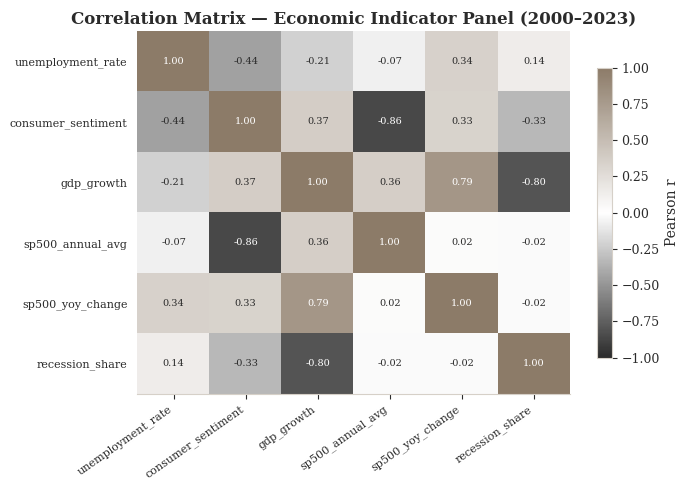

In [15]:
import matplotlib.colors as mcolors

corr = panel.corr()

fig, ax = plt.subplots(figsize=(7, 5))

# Custom diverging colormap anchored at white
cmap = mcolors.LinearSegmentedColormap.from_list(
    "fashion_div",
    [CHARCOAL, "white", ACCENT],
    N=256
)

im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")

labels = corr.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

# Annotate cells
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.values[i, j]
        text_color = "white" if abs(val) > 0.6 else CHARCOAL
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color=text_color)

ax.set_title("Correlation Matrix — Economic Indicator Panel (2000–2023)")
ax.tick_params(axis="y", left=False)
plt.tight_layout()
plt.savefig(f"{DATA}/../figures/economic_panel_corr.png", dpi=150, bbox_inches="tight")
plt.show()

### Commentary: What Each Indicator Adds

**`unemployment_rate`**
A lagging cyclical indicator; high unemployment persists well past recession
troughs.  Expected to correlate positively with muted runway colours because
designers responding to a downturn climate produce collections ~12–18 months
after the signal appears in labour data.

**`consumer_sentiment`**
A leading/coincident indicator that captures the *feel* of the economy more
quickly than GDP.  A falling UMCSENT reading may influence designers (and buyers)
toward conservative, less-conspicuous colour palettes — the psychological
transmission channel.

**`gdp_growth`**
Provides a continuous severity measure for recessions.  Negative GDP growth
quarters are more precise than binary NBER recession dates and allow for
graduated regression modelling.

**`sp500_annual_avg` / `sp500_yoy_change`**
Market returns are forward-looking and tend to *lead* the business cycle by 6–9
months.  A sharp YoY decline in the S&P 500 may signal to the fashion industry
that luxury spending will fall, encouraging a shift toward quieter, more
accessible aesthetics.

**`recession_share`**
Converts the binary USREC flag into a continuous 0–1 variable representing the
fraction of months in a given year that were officially in recession.  This
smooths out partial-year recessions (e.g., the short 2020 COVID recession) and
works better in regression models than a dummy variable.

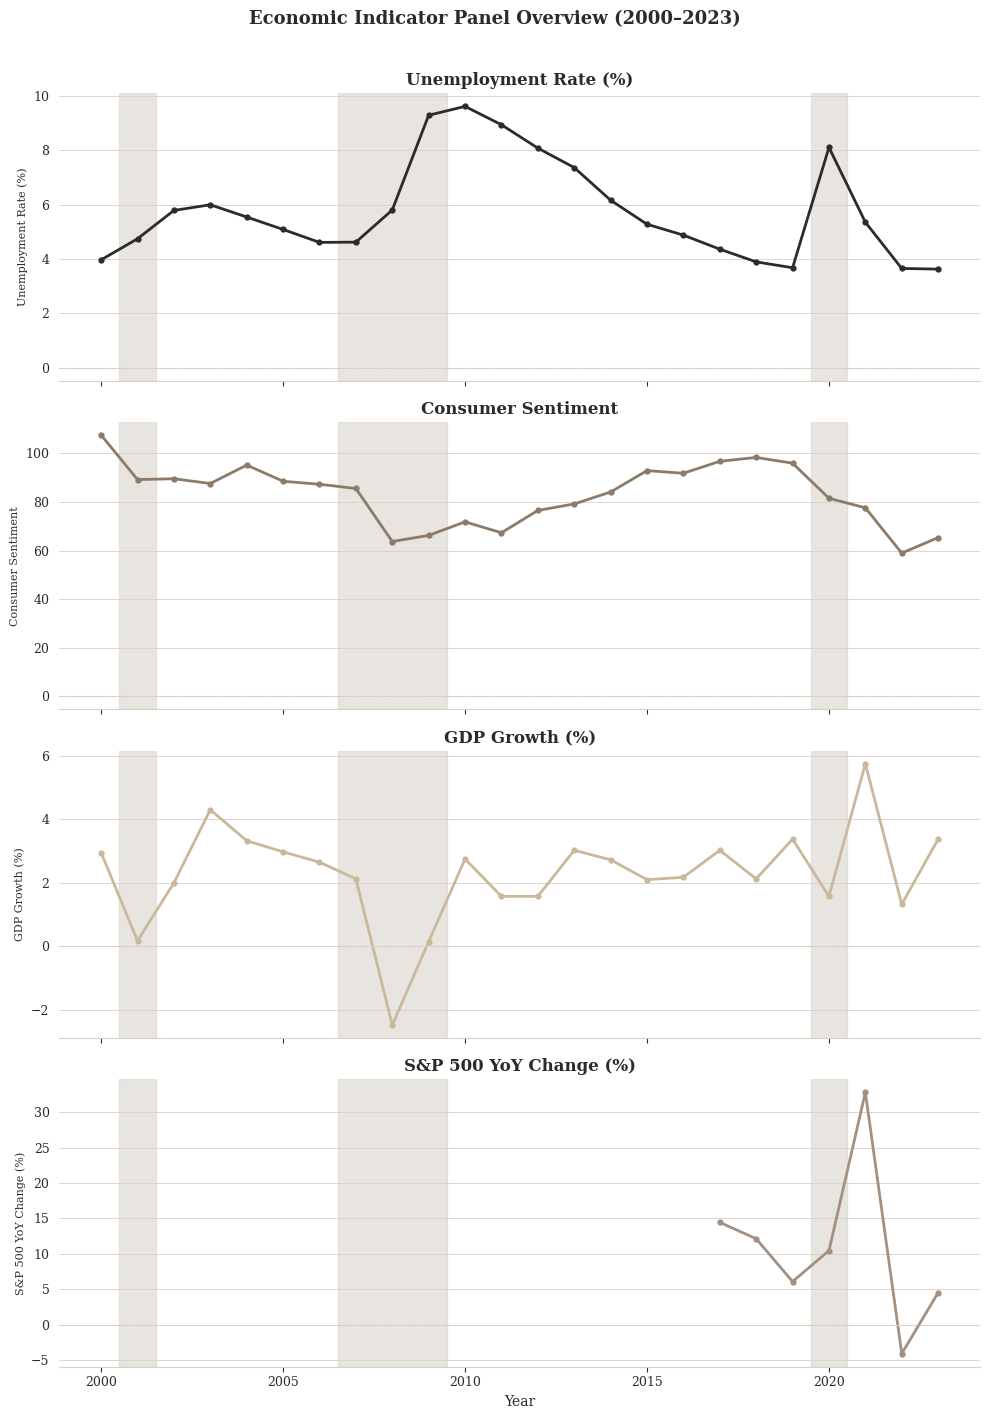

All figures saved to data/figures/


In [16]:
# ── 4-panel overview of the full economic indicator panel ────────────────────
fig, axes = plt.subplots(4, 1, figsize=(10, 14), sharex=True)

indicators = [
    ("unemployment_rate",  "Unemployment Rate (%)",    CHARCOAL),
    ("consumer_sentiment", "Consumer Sentiment",        ACCENT),
    ("gdp_growth",         "GDP Growth (%)",            SAND),
    ("sp500_yoy_change",   "S&P 500 YoY Change (%)",   "#a39080"),
]

for ax, (col, label, color) in zip(axes, indicators):
    shade_recessions(ax)
    ax.plot(panel.index, panel[col], color=color, linewidth=2.0, marker="o",
            markersize=3.5)
    ax.axhline(0, color=MIST, linewidth=0.8, linestyle="--")
    ax.set_title(label)
    ax.set_ylabel(label, fontsize=8)
    ax.yaxis.grid(True)
    ax.tick_params(axis="y", left=False)

axes[-1].set_xlabel("Year")
fig.suptitle("Economic Indicator Panel Overview (2000–2023)",
             fontsize=13, fontweight="bold", color=CHARCOAL, y=1.01)
plt.tight_layout()
plt.savefig(f"{DATA}/../figures/economic_panel_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("All figures saved to data/figures/")

---

## Next Steps

- **`02_color_extraction.ipynb`** — join `economic_panel_yearly.csv` with the
  existing CIELab colour metrics from Vogue Runway images.
- Run OLS / mixed-effects regressions: `lightness ~ recession_share + consumer_sentiment + …`
- Incorporate the Google Trends composite index as a demand-side robustness check.
- Consider a 1-year lag structure to account for the designer production cycle.